# Enzyme Design Pipeline
MH - 10/01/2026
KS - 21/01/2026
```
RFD3 → MPNN → RF3
```

This notebook is for designing enzymes from a known theozyme. 

## Create environment

### Install miniforge

Download miniforge3 and install it at your net scratch `/work3/$USER/` with:

```
cd /work3/$USER/
curl -L -O "https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-$(uname)-$(uname -m).sh"
bash Miniforge3-$(uname)-$(uname -m).sh
```

You can decide whether you want to auto-initialize the environment or not in the installation options. Before installing the environment make sure the conda base environment is activated. If it is activated your terminal should look something like this:

```
(base) /work3/user/projects/enzyme_design
hpclogin1(user) $ 
```

### install the enzyme design environment

This notebook is designed to run in the cgrp_env1 Conda environment, which already contains all required packages. You only need to register this environment as a Jupyter kernel once.

```
conda env create -f enzdes.yml
conda activate enzdes
python -m ipykernel install --user \
  --name cgrp_env1 \
  --display-name "enzdes"
```
Then, in Jupyter, select:
```
Kernel → enzdes
```
After that, you can run all cells in this notebook normally. You may need to restart your IDE if it does not show up immediately.

### Set Up: imports and directories

In [ ]:
# --- Core ---
import os, sys, re, glob, json, math, shutil, random, string, csv
import itertools
from pathlib import Path
from collections import Counter, defaultdict, OrderedDict
from datetime import datetime
from copy import deepcopy
from Bio import SeqIO
import jupyter_utils

# --- Data / numerics ---
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Notebook display ---
from IPython.display import display

In [ ]:
user     = os.environ.get('USER', '')
family   = 'hydrolases'       # enzyme family  (e.g. hydrolases, oxidoreductases)
target   = 'serine_hydrolase' # enzyme target
campaign = 'rd1'              # campaign / round identifier

working_dir = f'/work3/{user}/projects/enzyme_design/{family}/{target}/{campaign}'
os.makedirs(working_dir, exist_ok=True)
os.chdir(working_dir)

def setup_directories(base_dir, dirs_list):
    """Create subdirectories and return a dict mapping <name>_dir → full path."""
    result = {}
    for dir_name in dirs_list:
        full_path = os.path.join(base_dir, dir_name)
        os.makedirs(full_path, exist_ok=True)
        result[dir_name + '_dir'] = full_path
    return result

wrk_dirs_list = ['cmds', 'logs', 'pics', 'configs', 'scores', 'inputs',
                 'diffusion_out', 'rf3_out', 'mpnn_out']
_dirs = setup_directories(working_dir, wrk_dirs_list)

cmds_dir         = _dirs['cmds_dir']
logs_dir         = _dirs['logs_dir']
pics_dir         = _dirs['pics_dir']
configs_dir      = _dirs['configs_dir']
scores_dir       = _dirs['scores_dir']
inputs_dir       = _dirs['inputs_dir']
diffusion_out_dir = _dirs['diffusion_out_dir']
rf3_out_dir      = _dirs['rf3_out_dir']
mpnn_out_dir     = _dirs['mpnn_out_dir']

print(f"Campaign : {family} / {target} / {campaign}")
print(f"Directory: {working_dir}")

### RFD3

RFdiffusion3 (RFD3) generates de novo backbone structures by diffusing from noise under constraints you define — here, the catalytic residues are fixed in their theozyme geometry while the surrounding scaffold is designed freely.

Full parameter reference: [RFD3 enzyme design docs](https://github.com/RosettaCommons/foundry/blob/production/models/rfd3/docs/enzyme_design.md)

Key parameters to configure below:
- **`contig`**: scaffold layout — free segments like `30-50` are designed from scratch; entries like `A58-58` copy a residue directly from the input PDB. Commas separate segments; `/0` separates chains.
- **`catres`**: catalytic residues held fixed during MPNN sequence design.
- **`fixed_atoms`**: specific sidechain atoms on each catres to pin in place during diffusion (preserves catalytic geometry).
- **`ligand_name`**: must match the residue name in your input PDB (can be an arbitrary label for non-CCD ligands).

In [ ]:
dialect   = 2
input_pdb = f'{working_dir}/inputs/5XH3.pdb'

# Scaffold layout: free ranges (e.g. 30-50) interspersed with fixed motif residues (e.g. A58-58)
contig = "30-50,A58-58,40-60,A131-132,20-40,A177-177,20-40,A208,40-60"

# Total design length range (residues)
length = "180-250"

ligand_name              = "pt1"   # must match residue name in input PDB
redesign_motif_sidechains = False
is_non_loopy             = True    # biases diffusion toward helices; reduces loop content
infer_ori_strategy       = None    # use "hotspots" for binder design; None for enzyme design
hotspots                 = None

# Catalytic residues — MPNN will not redesign these
catres = ["A131", "A177", "A208"]  # ser, asp, his (serine protease triad)

# Key sidechain atoms to pin during diffusion (preserves catalytic geometry)
fixed_atoms = {
    "A131": "OG,CA,CB",
    "A177": "OD1,OD2,CG,CB",
    "A208": "NE2,ND1,CE1,CD2,CG",
}

select_hotspots       = {}
select_hbond_donor    = {}
select_hbond_acceptor = {}

In [ ]:
cmds      = f'{cmds_dir}/rfd3.cmds'
ckpt_path = "/dtu/projects/dbl/foundry/ckpt/rfd3_latest.ckpt"
diffusion_batch_size = 2
n_batches = 10

with open(cmds, 'w') as f:
    bn = os.path.basename(input_pdb)[:-4]

    # write config json
    json_f = f'{configs_dir}/{bn}.json'
    jupyter_utils.write_rfd3_json(json_f, input_pdb, contig, length,
                                  catres=','.join(catres), ligand=ligand_name,
                                  fixed_atoms=fixed_atoms, dialect=dialect,
                                  redesign_motif_sc=redesign_motif_sidechains,
                                  hotspots=hotspots, infer_ori_strategy=infer_ori_strategy)

    outdir = f'{diffusion_out_dir}/{bn}'
    os.makedirs(outdir, exist_ok=True)

    cmd = f'rfd3 design \
                out_dir={outdir} \
                inputs={json_f} \
                ckpt_path={ckpt_path} \
                diffusion_batch_size={diffusion_batch_size} \
                n_batches={n_batches} \
                inference_sampler.step_scale=3 \
                inference_sampler.gamma_0=0.2'
    f.write(cmd + '\n')

n_task = len(open(cmds).readlines())
jupyter_utils.make_sub_script(cmds=cmds, n_task=n_task, mem='10GB', time_limit='12:00',
                              cores=4, gpu='num=1:mode=exclusive_process',
                              queue='gpul40s', job_name='rfd3',
                              env='/dtu/projects/dbl/foundry/miniforge3/envs/rfd3',
                              python_path='/dtu/projects/dbl/foundry')

sub_script = cmds.replace('.cmds', '.sh')
print(f"Generated {n_task} RFD3 job(s).")
print(f"\nSubmit with:\n  bsub < {sub_script}\n")

#### Process rfd3 outputs

In [ ]:
rfd3_metrics_csv = f'{scores_dir}/rfd3_metrics_with_json_path.csv'

json_paths = sorted(glob.glob(f'{diffusion_out_dir}/*/*json'))
if not json_paths:
    raise SystemExit("No JSON files found — run RFD3 jobs first.")

rows = []
all_keys = set(["json_path"])

for jp in json_paths:
    with open(jp, "r") as f:
        data = json.load(f)

    metrics = data.get("metrics", {})
    row = {"json_path": os.path.abspath(jp)}
    for k, v in metrics.items():
        if k in ("diffused_com", "fixed_com") and isinstance(v, (list, tuple)) and len(v) == 3:
            row[f"{k}_x"], row[f"{k}_y"], row[f"{k}_z"] = v
            all_keys.update({f"{k}_x", f"{k}_y", f"{k}_z"})
        else:
            row[k] = v
            all_keys.add(k)
    rows.append(row)

fieldnames = ["json_path"] + sorted(k for k in all_keys if k != "json_path")

with open(rfd3_metrics_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in rows:
        writer.writerow(r)

print(f"Wrote {len(rows)} rows → {rfd3_metrics_csv}")
print("Columns:", fieldnames)

#### Inspect metrics

Review RFD3 output quality before moving to MPNN. Key columns:
- **`n_chainbreaks`**: must be 0 — broken chains are discarded before sequence design
- **`loop_fraction`**: lower is generally better; `is_non_loopy=True` above reduces this
- **`n_clashing.*`**: clash counts; structures with clashes are filtered before MPNN

In [5]:
df = pd.read_csv(rfd3_metrics_csv)
df.head(10)

,json_path,alanine_content,diffused_com_x,diffused_com_y,diffused_com_z,fixed_com_x,fixed_com_y,fixed_com_z,glycine_content,helix_fraction,...,n_chainbreaks,n_clashing.interresidue_clashes_w_backbone,n_clashing.interresidue_clashes_w_sidechain,n_clashing.ligand_clashes,n_clashing.ligand_min_distance,non_loop_fraction,num_residues,num_ss_elements,radius_of_gyration,sheet_fraction
0,/work3/kiersum/projects/enzyme_design/hydrolas...,0.595652,3.176254,2.425249,-0.430946,0.000581,-0.000277,0.000977,0.095652,0.837004,...,0,0,0,0,2.457270,0.837004,230,11,16.024190,0.0
1,/work3/kiersum/projects/enzyme_design/hydrolas...,0.608696,-1.310652,0.044303,-1.658546,0.000581,-0.000277,0.000977,0.073913,0.850220,...,0,0,0,0,2.803225,0.850220,230,10,17.675027,0.0
2,/work3/kiersum/projects/enzyme_design/hydrolas...,0.622407,2.505678,0.783840,-2.449991,0.000581,-0.000277,0.000977,0.070539,0.873950,...,1,0,1,0,2.224554,0.873950,241,11,17.889793,0.0
3,/work3/kiersum/projects/enzyme_design/hydrolas...,0.626556,-1.562880,4.208344,-0.461365,0.000581,-0.000277,0.000977,0.082988,0.857143,...,0,0,1,0,1.783891,0.857143,241,8,19.387471,0.0
4,/work3/kiersum/projects/enzyme_design/hydrolas...,0.578431,-0.868815,0.044279,-1.464917,0.000581,-0.000277,0.000977,0.068627,0.796020,...,0,0,0,0,1.851160,0.796020,204,11,16.164563,0.0
5,/work3/kiersum/projects/enzyme_design/hydrolas...,0.553922,0.520657,1.311442,-2.813896,0.000581,-0.000277,0.000977,0.088235,0.845771,...,0,1,2,0,1.824856,0.845771,204,10,16.720780,0.0
6,/work3/kiersum/projects/enzyme_design/hydrolas...,0.612022,-0.529357,4.937172,-1.784351,0.000581,-0.000277,0.000977,0.076503,0.833333,...,0,0,0,0,2.021161,0.833333,183,8,16.956765,0.0
7,/work3/kiersum/projects/enzyme_design/hydrolas...,0.644809,-1.633841,2.943006,-3.478458,0.000581,-0.000277,0.000977,0.054645,0.872222,...,0,0,0,0,3.028096,0.872222,183,9,17.107004,0.0
8,/work3/kiersum/projects/enzyme_design/hydrolas...,0.580645,-0.888873,0.665892,-2.667241,0.000581,-0.000277,0.000977,0.078341,0.827103,...,0,0,0,0,2.882395,0.827103,217,10,16.883548,0.0
9,/work3/kiersum/projects/enzyme_design/hydrolas...,0.594470,-1.149121,-0.011218,-1.352111,0.000581,-0.000277,0.000977,0.082949,0.817757,...,0,0,1,0,1.843116,0.817757,217,11,16.488802,0.0


Plotting: ['alanine_content', 'glycine_content', 'helix_fraction', 'loop_fraction', 'sheet_fraction', 'max_ca_deviation', 'n_chainbreaks', 'n_clashing.interresidue_clashes_w_backbone', 'n_clashing.interresidue_clashes_w_sidechain', 'non_loop_fraction', 'radius_of_gyration']


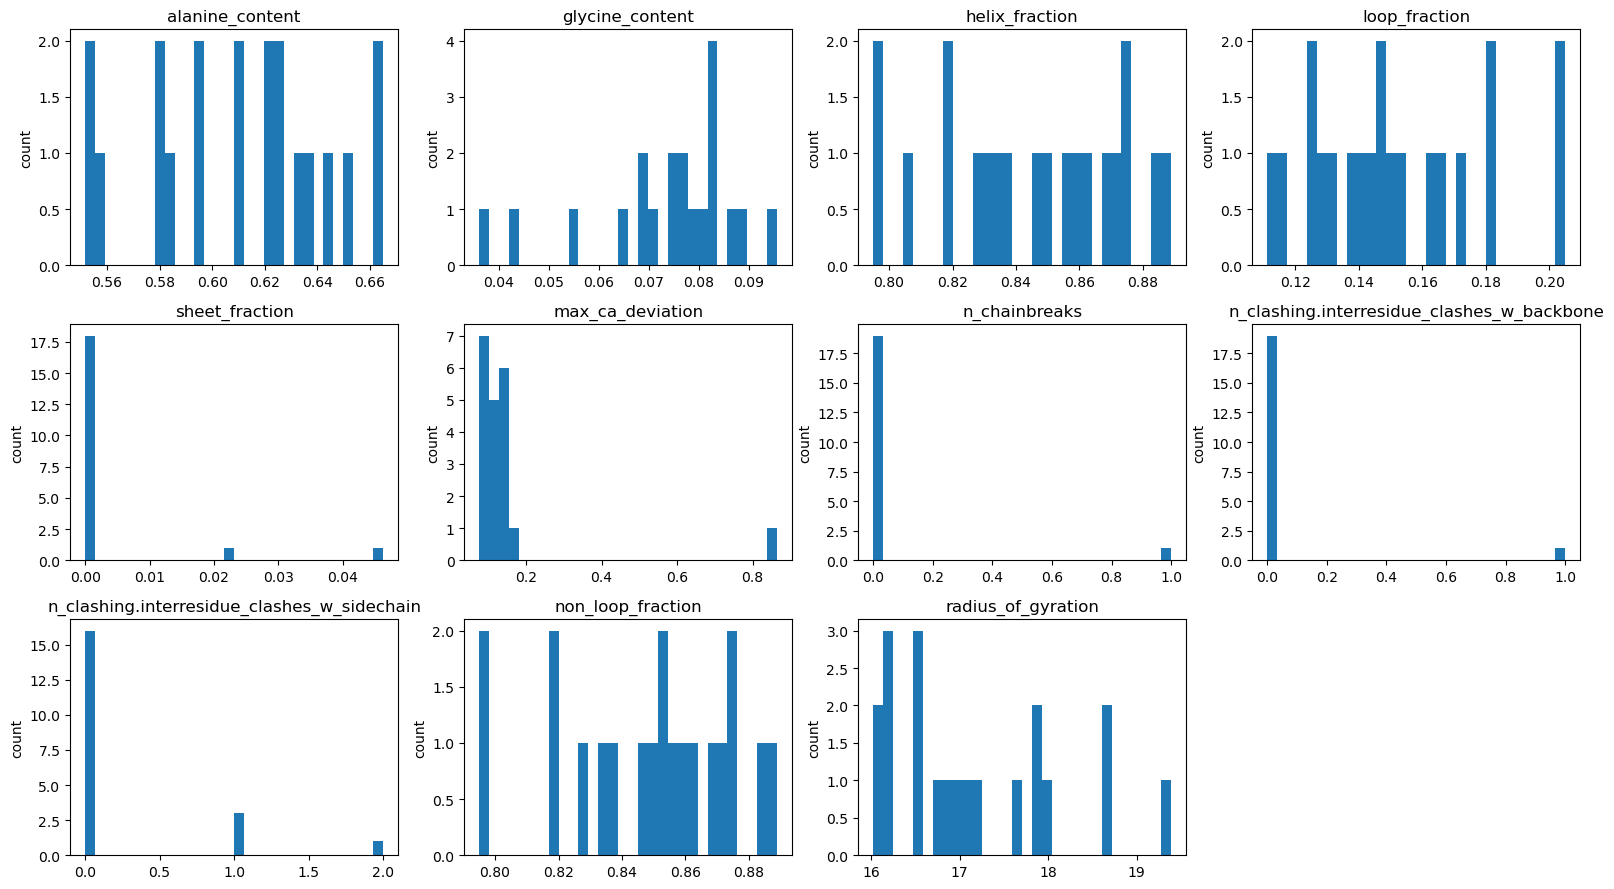

In [6]:
metrics = [
    "alanine_content",
    "glycine_content",
    "helix_fraction",
    "loop_fraction",
    "sheet_fraction",
    "max_ca_deviation",
    "n_chainbreaks",
    "n_clashing.interresidue_clashes_w_backbone",
    "n_clashing.interresidue_clashes_w_sidechain",
    "non_loop_fraction",
    "radius_of_gyration",
]

# Keep only columns that exist (safety)
metrics = [m for m in metrics if m in df.columns]

print("Plotting:", metrics)

n_metrics = len(metrics)
n_cols = 4
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

def plot_hist(ax, series, title):
    s = series.dropna()
    if s.empty:
        ax.set_title(f"{title} (no data)")
        ax.axis("off")
        return
    ax.hist(s, bins=30)
    ax.set_title(title)
    ax.set_ylabel("count")

for ax, col in zip(axes, metrics):
    plot_hist(ax, df[col], col)

# Turn off unused axes
for ax in axes[len(metrics):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### MPNN

LigandMPNN designs amino acid sequences onto each generated backbone, conditioning on the small-molecule ligand context. Catalytic residues are held fixed. Structures with chain breaks or clashes are discarded before sequence design.

In [ ]:
seed              = 42
batch_size        = 10   # sequences per structure
number_of_batches = 1    # total sequences per design = batch_size × number_of_batches
ckpt              = '/dtu/projects/dbl/LigandMPNN/25.3.1-0//model_params/ligandmpnn_v_32_010_25.pt'
chains_to_design  = 'A'  # chain(s) to redesign; catres will be kept fixed regardless
remove_bad_structures = True

In [10]:
sys.path.append("/dtu/projects/dbl/proteusai/latest/src/")
from pai.metrics.structure import compute_structure_metrics
from atomworks.io import parse

Environment variable CCD_MIRROR_PATH not set. Will not be able to use function requiring this variable. To set it you may:
  (1) add the line 'export VAR_NAME=path/to/variable' to your .bashrc or .zshrc file
  (2) set it in your current shell with 'export VAR_NAME=path/to/variable'
  (3) write it to a .env file in the root of the atomworks.io repository
Environment variable PDB_MIRROR_PATH not set. Will not be able to use function requiring this variable. To set it you may:
  (1) add the line 'export VAR_NAME=path/to/variable' to your .bashrc or .zshrc file
  (2) set it in your current shell with 'export VAR_NAME=path/to/variable'
  (3) write it to a .env file in the root of the atomworks.io repository


In [ ]:
cmds = f'{cmds_dir}/mpnn.cmds'
bad_structure_count = 0

with open(cmds, 'w') as f:
    for structure in sorted(glob.glob(f'{diffusion_out_dir}/*/*cif.gz')):
        if remove_bad_structures:
            struct = parse(structure)
            metrics = compute_structure_metrics(struct["asym_unit"][0])
            if metrics["n_chainbreaks"] > 0 or metrics["n_clashes_sidechain"] > 0 or metrics["n_clashes_backbone"] > 0:
                bad_structure_count += 1
                continue

        bn = os.path.basename(structure).replace('.cif.gz', '').replace('.pdb', '')
        this_outdir = f'{mpnn_out_dir}/{bn}'
        os.makedirs(this_outdir, exist_ok=True)

        data = json.load(open(structure.replace('.cif.gz', '.json'), 'r'))
        fixed_resi = [data['diffused_index_map'][resi] for resi in catres]
        fixed_resis = ' '.join(fixed_resi)

        cmd = f'python /dtu/projects/dbl/LigandMPNN/25.3.1-0/run.py \
                --seed {seed} \
                --pdb_path "{structure}" \
                --out_folder "{this_outdir}" \
                --fixed_residues "{fixed_resis}" \
                --batch_size {batch_size} \
                --number_of_batches {number_of_batches} \
                --model_type "ligand_mpnn" \
                --checkpoint_ligand_mpnn "{ckpt}" \
                --chains_to_design "{chains_to_design}" '
        f.write(cmd + '\n')

print(f'Removed {bad_structure_count} structures with clashes or chain breaks before design.')

n_tasks = len(open(cmds).readlines())
jupyter_utils.make_sub_script(cmds, n_task=n_tasks, group_size=10, mem='10G', queue='hpc',
                              job_name='mpnn', cores=4, time_limit='2:00',
                              python_path='/dtu/projects/dbl/LigandMPNN/25.3.1-0/',
                              env='/dtu/projects/dbl/LigandMPNN/25.3.1-0//miniforge3/envs/ligandmpnn_env')

sub_script = cmds.replace('.cmds', '.sh')
print(f"Generated {n_tasks} MPNN job(s).")
print(f"\nSubmit with:\n  bsub < {sub_script}\n")

### RF3

RosettaFold3 (RF3) predicts the full all-atom structure of each MPNN-designed sequence in complex with the ligand. This is the validation step — high pLDDT and low PAE indicate a confident, well-packed design.

The script below iterates over all MPNN FASTA files, skips the first sequence (the original RFD3 backbone with alanine fill), and writes one RF3 JSON per designed sequence into `configs/rf3/`.

#### Create cmds

In [ ]:
# Ligand specification for RF3
# RF3 needs chemistry to place the ligand — provide a SMILES string if your ligand
# is not in the Chemical Component Database (CCD).
ligand_name = "pt1"    # must match the residue name in your input PDB
ccd_ligand  = False    # set True if your ligand has a standard CCD code (e.g. "HEM", "ATP")
smiles_str  = "COC(=O)c1ccc(C(=O)OCCO)cc1"  # required when ccd_ligand=False

if not ccd_ligand and not smiles_str:
    print("WARNING: ligand is not in CCD — you must provide a SMILES string or SDF.")

ligand_entry = {"smiles": smiles_str} if smiles_str else ligand_name

In [27]:
ligand_entry

{'smiles': 'COC(=O)c1ccc(C(=O)OCCO)cc1'}

In [ ]:
cmds      = f'{cmds_dir}/rf3.cmds'
ckpt_path = "/dtu/projects/dbl/rf3/release/ckpt/rf3_latest.pt"
num_steps = 50   # 50 for speed; increase to 200 for higher-quality production runs
# --------------------------------------
os.makedirs(f'{configs_dir}/rf3', exist_ok=True)

fasta_fs = sorted(glob.glob(f'{mpnn_out_dir}/*/seqs/*cif.gz.fa'))

with open(cmds, 'w') as f:
    for fasta_f in fasta_fs:
        results = []
        name    = os.path.basename(fasta_f).split('.')[0]
        json_f  = f'{configs_dir}/rf3/{name}.json'
        out_dir = f'{rf3_out_dir}/{name}'
        os.makedirs(out_dir, exist_ok=True)

        for i, r in enumerate(SeqIO.parse(fasta_f, 'fasta')):
            if i == 0:
                continue  # skip original RFD3 backbone (alanine-filled sequence)
            results.append({
                "name": f'{name}_{i}',
                "components": [
                    {"seq": str(r.seq).split(':')[0], "chain_id": "A"},
                    ligand_entry,
                ]
            })

        with open(json_f, "w") as out_f:
            json.dump(results, out_f, indent=4)

        cmd = (f'rf3 fold inference_engine=rf3 inputs={json_f} '
               f'out_dir={out_dir} ckpt_path={ckpt_path} '
               f'num_steps={num_steps} annotate_b_factor_with_plddt=True '
               f'early_stopping_plddt_threshold=0')
        f.write(cmd + '\n')

n_task = len(open(cmds).readlines())
jupyter_utils.make_sub_script(cmds=cmds, n_task=n_task, mem='10GB', time_limit='4:00',
                              group_size=10, cores=4,
                              gpu='num=1:mode=exclusive_process',
                              queue='gpua100', job_name='rf3',
                              env='/dtu/projects/dbl/rf3/release/conda_envs/rf3-env',
                              python_path='/dtu/projects/dbl/rf3/release')

sub_script = cmds.replace('.cmds', '.sh')
print(f"Generated {n_task} RF3 job(s) across {len(fasta_fs)} FASTA file(s).")
print(f"\nSubmit with:\n  bsub < {sub_script}\n")

#### Filter and inspect RF3 outputs

Gather RF3 confidence metrics from all predictions. Key metrics:
- **`plddt`**: overall model confidence (0–1); aim for > 0.7
- **`ptm`**: predicted TM-score; higher is better

In [ ]:
plddt_threshold = 0.7  # minimum acceptable pLDDT; adjust to your campaign standards

metric_csvs = sorted(glob.glob(f'{rf3_out_dir}/**/*_metrics.csv', recursive=True))

if not metric_csvs:
    print("No RF3 metrics CSVs found — run RF3 jobs first.")
else:
    dfs = []
    for csv_path in metric_csvs:
        df_m = pd.read_csv(csv_path)
        df_m.insert(0, 'design_id', os.path.basename(os.path.dirname(csv_path)))
        dfs.append(df_m)

    df_rf3 = pd.concat(dfs, ignore_index=True)
    print(f"Total RF3 predictions : {len(df_rf3)}")
    print(f"Available columns     : {list(df_rf3.columns)}\n")

    # auto-detect pLDDT column (RF3 may name it 'plddt' or 'mean_plddt')
    plddt_col = next((c for c in df_rf3.columns if 'plddt' in c.lower()), None)

    if plddt_col:
        df_pass = df_rf3[df_rf3[plddt_col] >= plddt_threshold]
        print(f"Passing (pLDDT ≥ {plddt_threshold}): {len(df_pass)} / {len(df_rf3)}")
        display(df_rf3.sort_values(plddt_col, ascending=False).head(10))

        ranked = df_rf3.sort_values(plddt_col, ascending=False).reset_index(drop=True)
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.scatter(ranked.index, ranked[plddt_col], alpha=0.75, s=20)
        ax.axhline(plddt_threshold, color='tomato', linestyle='--',
                   label=f'threshold ({plddt_threshold})')
        ax.set_xlabel('design rank')
        ax.set_ylabel(plddt_col)
        ax.set_title('RF3 pLDDT — ranked designs')
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Could not auto-detect pLDDT column — check columns above and filter manually.")
        display(df_rf3.head())